# Portfolio Optimization #

In [1]:
# Import Libraries #
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
#List of stocks in the portfolio
stocks = ["TCS.NS", "RELIANCE.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]

In [3]:
#Download the price history of stocks
data = yf.download(stocks,start="1999-01-01",auto_adjust=True)["Close"] #Auto adjust is used to adjust for splits, dividends, and other stock related things.
data.dropna(inplace=True)

data.head()
#Data available is only post 12th August, 2002

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2002-08-12,8.724617,17.485079,31.083256,13.248800,25.828400
2002-08-13,8.795312,17.478565,31.091930,13.336778,25.478718
2002-08-14,8.662240,17.218275,30.422701,13.116832,23.722124
2002-08-15,8.662240,17.218275,30.422701,13.116832,23.722124
2002-08-16,8.745409,17.465557,30.919086,13.350522,23.665182


In [4]:
#Calculating % change in stock price on a day to day basis.
dreturns=data.pct_change()
dreturns.dropna(inplace=True)
dreturns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2002-08-13,0.008103,-0.000373,0.000279,0.006640,-0.013539
2002-08-14,-0.015130,-0.014892,-0.021524,-0.016492,-0.068944
2002-08-15,0.000000,0.000000,0.000000,0.000000,0.000000
2002-08-16,0.009601,0.014362,0.016316,0.017816,-0.002400
2002-08-19,0.003329,0.012668,0.005403,0.010091,-0.024742


In [5]:
dreturns.describe()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
count,5879.000000,5879.000000,5879.000000,5879.000000,5879.000000
mean,0.000929,0.001014,0.000809,0.001423,0.001191
std,0.018151,0.023547,0.019347,0.049307,0.035440
min,-0.206437,-0.198567,-0.265466,-0.769945,-0.506111
25%,-0.007756,-0.010828,-0.008980,-0.009728,-0.008117
50%,0.000360,0.000178,0.000436,0.000581,0.000000
75%,0.009212,0.011894,0.010424,0.011114,0.009229
max,0.258174,0.230381,0.167851,3.374776,2.018887


In [6]:
cov_matrix = dreturns.cov()
cov_matrix
yearlycov=cov_matrix*252
yearlycov
#Covariance of any stock vs its own, in the below matrix is non-zero, because, the value represents its own variance.

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,0.083023,0.061286,0.027166,0.041492,0.028225
ICICIBANK.NS,0.061286,0.139721,0.035782,0.073489,0.041893
INFY.NS,0.027166,0.035782,0.094327,0.031393,0.052352
RELIANCE.NS,0.041492,0.073489,0.031393,0.612650,0.197070
TCS.NS,0.028225,0.041893,0.052352,0.197070,0.316516


In [7]:
diverseweights=np.random.random(5)  #Generates 5 different decimals, randomly.
diverseweights=diverseweights/np.sum(diverseweights)  
#We divide the randomly generated decimals, by the sum of all decimals. Resultant array will have decimals summing up to 1.

OverallYearlyReturn = np.sum(diverseweights * dreturns.mean()) * 252      #There are 252 trading days per year.
OverallYearlyReturn

np.float64(0.2730628012157066)

In [8]:
portfolio_volatility=np.sqrt(np.dot(diverseweights, np.dot(yearlycov, diverseweights)))
portfolio_volatility

np.float64(0.31732700815862774)

In [12]:
#Sharpe_ratio = (Rate of Return-Risk Free Rate)/Risk.
#Most optimum portfolio will have the highest Sharpe ratio.
weights_list=[]
sharpe_list=[]
volatility_list=[]
returns_list=[]
meandreturns=dreturns.mean()
for i in range(5000):
    weights=np.random.random(5)
    weights=weights/np.sum(weights)  
    yearlyreturn=np.sum(weights * meandreturns) * 252
    returns_list.append(yearlyreturn)
    volatility=np.sqrt(np.dot(weights, np.dot(yearlycov, weights)))
    volatility_list.append(volatility)
    sharpe=(yearlyreturn-0.0695)/volatility     #Risk Free Rate in India is 6.95%
    sharpe_list.append(sharpe)
    weights_list.append(weights)
max_index = sharpe_list.index(max(sharpe_list))
print(sharpe_list[max_index])
print(weights_list[max_index])

0.7080720787378018
[0.37697729 0.19389152 0.23820406 0.06252055 0.12840658]


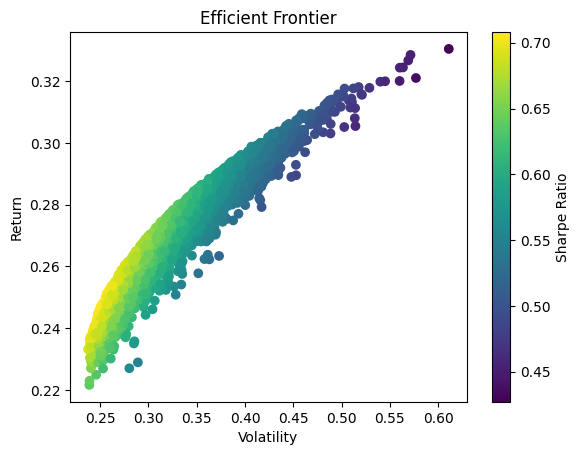

In [13]:
plt.scatter(volatility_list, returns_list, c=sharpe_list)
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.show()

In [18]:
print("Best Portfolio Allocation:")
i=0
for a in stocks:
    print("Percent allocation for",a,(weights_list[max_index][i]*100).round(2),"%")
    i=i+1

Best Portfolio Allocation:
Percent allocation for TCS.NS 37.7 %
Percent allocation for RELIANCE.NS 19.39 %
Percent allocation for HDFCBANK.NS 23.82 %
Percent allocation for INFY.NS 6.25 %
Percent allocation for ICICIBANK.NS 12.84 %
